# **Kaggle – DataTops®**
Tu TA ha decidido cambiar de aires y, por eso, ha comprado una tienda de portátiles. Sin embargo, su única especialidad es Data Science, por lo que ha decidido crear un modelo de ML para establecer los mejores precios.

¿Podrías ayudar a tu profe a mejorar ese modelo?

## Aspectos importantes
- Última submission:
    - Mañana: 17 de febrero a las 5pm
    - Tarde: 19 de febrero a las 5pm
- **Enlace de la competición**: https://www.kaggle.com/t/c5cc87b50c4b4770bdc8f5acbe15577d
- **Requisito**: Estar registrado en [Kaggle](https://www.kaggle.com/)

## Métrica:
El error cuadrático medio (RMSE, por sus siglas en inglés) es una medida de la desviación estándar de los residuos (errores de predicción). Los residuos representan la diferencia entre los valores observados y los valores predichos por el modelo. El RMSE indica qué tan dispersos están estos errores: cuanto menor es el RMSE, más cercanas están las predicciones a los valores reales. En otras palabras, el RMSE mide qué tan bien se ajusta la línea de regresión a los datos.


$$ RMSE = \sqrt{\frac{1}{n}\Sigma_{i=1}^{n}{\Big(\frac{d_i -f_i}{\sigma_i}\Big)^2}}$$


## 1. Librerías

In [1]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import urllib.request

## 2. Datos

In [3]:
# Para que funcione necesitas bajarte los archivos de datos de Kaggle
df = pd.read_csv("./data/train.csv")

### 2.1 Exploración de los datos

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         912 non-null    int64  
 1   Company           912 non-null    object 
 2   Product           912 non-null    object 
 3   TypeName          912 non-null    object 
 4   Inches            912 non-null    float64
 5   ScreenResolution  912 non-null    object 
 6   Cpu               912 non-null    object 
 7   Ram               912 non-null    object 
 8   Memory            912 non-null    object 
 9   Gpu               912 non-null    object 
 10  OpSys             912 non-null    object 
 11  Weight            912 non-null    object 
 12  Price_in_euros    912 non-null    float64
dtypes: float64(2), int64(1), object(10)
memory usage: 92.8+ KB


In [5]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
0,755,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.86kg,539.00
1,618,Dell,Inspiron 7559,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16GB,1TB HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.59kg,879.01
2,909,HP,ProBook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.04kg,900.00
3,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
4,286,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,AMD Radeon R5 M430,Linux,2.25kg,428.00


In [6]:
df.tail()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
907,28,Dell,Inspiron 5570,Notebook,15.6,Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,256GB SSD,AMD Radeon 530,Windows 10,2.2kg,800.00
908,1160,HP,Spectre Pro,2 in 1 Convertible,13.3,Full HD / Touchscreen 1920x1080,Intel Core i5 6300U 2.4GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.48kg,1629.00
909,78,Lenovo,IdeaPad 320-15IKBN,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,2TB HDD,Intel HD Graphics 620,No OS,2.2kg,519.00
910,23,HP,255 G6,Notebook,15.6,1366x768,AMD E-Series E2-9000e 1.5GHz,4GB,500GB HDD,AMD Radeon R2,No OS,1.86kg,258.00
911,229,Dell,Alienware 17,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows 10,4.42kg,2456.34


In [7]:
df.describe()

,laptop_ID,Inches,Price_in_euros
count,912.000000,912.000000,912.000000
mean,650.312500,14.981579,1111.724090
std,382.727748,1.436719,687.959172
min,2.000000,10.100000,174.000000
25%,324.750000,14.000000,589.000000
50%,636.500000,15.600000,978.000000
75%,982.250000,15.600000,1483.942500
max,1320.000000,18.400000,6099.000000


### 2.3 Definir X e y

In [8]:
X = df.drop(['Price_in_euros'], axis=1)
y = df['Price_in_euros'].copy()
X.shape

(912, 12)

In [9]:
y.shape

(912,)

### 2.4 Dividir X_train, X_test, y_train, y_test

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [11]:
X_train

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
25,1118,HP,ZBook 17,Workstation,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,8GB,1TB HDD,AMD FirePro W6150M,Windows 7,3.0kg
84,153,Dell,Inspiron 5577,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1050,Windows 10,2.56kg
10,275,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.9GHz,8GB,512GB SSD,Intel Iris Graphics 550,macOS,1.37kg
342,1100,HP,EliteBook 840,Notebook,14.0,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,4GB,500GB HDD,Intel HD Graphics 520,Windows 7,1.54kg
890,131,Dell,Inspiron 5770,Notebook,17.3,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,16GB,256GB SSD + 2TB HDD,AMD Radeon 530,Windows 10,2.8kg
...,...,...,...,...,...,...,...,...,...,...,...,...
106,578,HP,14-am079na (N3710/8GB/2TB/W10),Notebook,14.0,1366x768,Intel Pentium Quad Core N3710 1.6GHz,8GB,2TB HDD,Intel HD Graphics 405,Windows 10,1.94kg
270,996,Lenovo,IdeaPad 320-15ABR,Notebook,15.6,Full HD 1920x1080,AMD A12-Series 9720P 3.6GHz,6GB,256GB SSD,AMD Radeon 530,Windows 10,2.2kg
860,770,Dell,Latitude 7280,Ultrabook,12.5,Full HD 1920x1080,Intel Core i7 7600U 2.8GHz,16GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.18kg
435,407,Lenovo,IdeaPad 320-15IAP,Notebook,15.6,1366x768,Intel Celeron Dual Core N3350 1.1GHz,4GB,1TB HDD,Intel HD Graphics 500,Windows 10,2.2kg


In [12]:
col = X_train.columns.to_list()

for c in col:
    print(f'Para la columna {c}, hay estas clases:{X_train[c].nunique()}')

Para la columna laptop_ID, hay estas clases:729
Para la columna Company, hay estas clases:17
Para la columna Product, hay estas clases:408
Para la columna TypeName, hay estas clases:6
Para la columna Inches, hay estas clases:15
Para la columna ScreenResolution, hay estas clases:33
Para la columna Cpu, hay estas clases:93
Para la columna Ram, hay estas clases:8
Para la columna Memory, hay estas clases:33
Para la columna Gpu, hay estas clases:84
Para la columna OpSys, hay estas clases:9
Para la columna Weight, hay estas clases:148


**Convertir variables a numéricas**

In [13]:
def preprocess_features(df):
    df = df.copy()

    # ------------------------------
    # 1. RAM
    df["Ram"] = df["Ram"].str.replace("GB","").astype(int)

    # ------------------------------
    # 2. Weight
    df["Weight"] = df["Weight"].str.replace("kg","").astype(float)

    # ------------------------------
    # 3. ScreenResolution
    df["X_res"] = df["ScreenResolution"].str.extract(r'(\d+)x').astype(int)
    df["Y_res"] = df["ScreenResolution"].str.extract(r'x(\d+)').astype(int)
    df["PPI"] = ((df["X_res"]**2 + df["Y_res"]**2)**0.5 / df["Inches"])

    df["IPS"] = df["ScreenResolution"].str.contains("IPS", case=False).astype(int)
    df["Touchscreen"] = df["ScreenResolution"].str.contains("Touchscreen", case=False).astype(int)

    df["Aspect"] = df["X_res"] / df["Y_res"]

    # ------------------------------
    # 4. CPU
    df["Cpu_freq"] = df["Cpu"].str.extract(r'(\d+\.\d+)').astype(float)
    df["Cpu_freq"] = df["Cpu_freq"].fillna(df["Cpu_freq"].median())

    df["Cpu_brand"] = df["Cpu"].str.split().str[0]
    df["Cpu_model"] = df["Cpu"].str.extract(r'(i3|i5|i7|i9|Ryzen 3|Ryzen 5|Ryzen 7|Ryzen 9)', expand=False)
    df["Cpu_model"] = df["Cpu_model"].fillna("Other")

    df["Cpu_gen"] = df["Cpu"].str.extract(r'(\d+)(?:th|st|nd|rd) Gen', expand=False)
    df["Cpu_gen"] = df["Cpu_gen"].fillna(0).astype(int)

    # ------------------------------
    # 5. Memory
    df["SSD"] = df["Memory"].str.extract(r'(\d+)GB SSD').fillna(0).astype(int)
    df["HDD"] = df["Memory"].str.extract(r'(\d+)GB HDD').fillna(0).astype(int)
    df["Flash"] = df["Memory"].str.extract(r'(\d+)GB Flash').fillna(0).astype(int)
    df["Hybrid"] = df["Memory"].str.contains("Hybrid", case=False).astype(int)

    # ------------------------------
    # 6. GPU
    df["Gpu_brand"] = df["Gpu"].str.split().str[0]
    df["Gpu_model"] = df["Gpu"].str.extract(r'(GTX|RTX|Radeon|Iris|HD|UHD)', expand=False)
    df["Gpu_model"] = df["Gpu_model"].fillna("Other")

    # ------------------------------
    # 7. Dummies
    cat_cols = ["Company", "TypeName", "Cpu_brand", "Cpu_model", "Gpu_brand", "Gpu_model", "OpSys"]
    df = pd.get_dummies(df, columns=cat_cols, drop_first=False)

    # ------------------------------
    # 8. Drop original text columns
    df = df.drop(columns=["ScreenResolution", "Cpu", "Memory", "Gpu", "Product"], errors="ignore")

    # ==========================================================
    # 9. FEATURE ENGINEERING AVANZADO
    # ==========================================================

    df["Total_storage"] = df["SSD"] + df["HDD"] + df["Flash"]

    df["Has_SSD"] = (df["SSD"] > 0).astype(int)
    df["Has_HDD"] = (df["HDD"] > 0).astype(int)
    df["Has_Flash"] = (df["Flash"] > 0).astype(int)

    df["Perf_score"] = df["Ram"] * df["Cpu_freq"]

    df["Gpu_power"] = (
        df.filter(like="Gpu_model_GTX").sum(axis=1) * 3 +
        df.filter(like="Gpu_model_RTX").sum(axis=1) * 4 +
        df.filter(like="Gpu_brand_Nvidia").sum(axis=1) * 2 +
        df.filter(like="Gpu_model_HD").sum(axis=1) * 1
    )

    df["Ram_freq"] = df["Ram"] * df["Cpu_freq"]
    df["PPI_weight"] = df["PPI"] / df["Weight"]
    df["Resolution_pixels"] = df["X_res"] * df["Y_res"]

    # ------------------------------
    # 10. Bins robustos (sin NaN)
    # ------------------------------

    # RAM bins
    df["Ram_bin"] = pd.cut(
        df["Ram"],
        bins=[0,4,8,16,32,128],
        labels=[0,1,2,3,4],
        include_lowest=True
    )
    df["Ram_bin"] = df["Ram_bin"].cat.add_categories([-1]).fillna(-1).astype(int)

    # Weight bins
    df["Weight_bin"] = pd.qcut(
        df["Weight"],
        q=4,
        labels=[0,1,2,3],
        duplicates="drop"
    )
    df["Weight_bin"] = df["Weight_bin"].cat.add_categories([-1]).fillna(-1).astype(int)

    return df


In [14]:
X_train = preprocess_features(X_train)
X_test = preprocess_features(X_test)


C:\Users\blanc\AppData\Local\Temp\ipykernel_7452\3455898259.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Cpu_gen"] = df["Cpu_gen"].fillna(0).astype(int)
C:\Users\blanc\AppData\Local\Temp\ipykernel_7452\3455898259.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Cpu_gen"] = df["Cpu_gen"].fillna(0).astype(int)


In [15]:
X_train

,laptop_ID,Inches,Ram,Weight,X_res,Y_res,PPI,IPS,Touchscreen,Aspect,...,Has_SSD,Has_HDD,Has_Flash,Perf_score,Gpu_power,Ram_freq,PPI_weight,Resolution_pixels,Ram_bin,Weight_bin
25,1118,17.3,8,3.00,1920,1080,127.335675,1,0,1.777778,...,0,0,0,20.8,0.0,20.8,42.445225,2073600,1,3
84,153,15.6,16,2.56,1920,1080,141.211998,0,0,1.777778,...,1,0,0,44.8,5.0,44.8,55.160937,2073600,2,3
10,275,13.3,8,1.37,2560,1600,226.983005,1,0,1.600000,...,1,0,0,23.2,0.0,23.2,165.681025,4096000,1,0
342,1100,14.0,4,1.54,1920,1080,157.350512,0,0,1.777778,...,0,1,0,9.2,1.0,9.2,102.175657,2073600,0,1
890,131,17.3,16,2.80,1920,1080,127.335675,0,0,1.777778,...,1,0,0,28.8,0.0,28.8,45.477027,2073600,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,578,14.0,8,1.94,1366,768,111.935204,0,0,1.778646,...,0,0,0,12.8,1.0,12.8,57.698559,1049088,1,1
270,996,15.6,6,2.20,1920,1080,141.211998,0,0,1.777778,...,1,0,0,21.6,0.0,21.6,64.187272,2073600,1,2
860,770,12.5,16,1.18,1920,1080,176.232574,0,0,1.777778,...,1,0,0,44.8,1.0,44.8,149.349639,2073600,2,0
435,407,15.6,4,2.20,1366,768,100.454670,0,0,1.778646,...,0,0,0,4.4,1.0,4.4,45.661214,1049088,0,2


In [16]:
X_test

,laptop_ID,Inches,Ram,Weight,X_res,Y_res,PPI,IPS,Touchscreen,Aspect,...,Has_SSD,Has_HDD,Has_Flash,Perf_score,Gpu_power,Ram_freq,PPI_weight,Resolution_pixels,Ram_bin,Weight_bin
649,451,15.6,8,2.20,1920,1080,141.211998,1,0,1.777778,...,1,0,0,22.4,5.0,22.4,64.187272,2073600,1,2
761,802,15.6,8,2.08,1920,1080,141.211998,0,1,1.777778,...,1,0,0,20.0,0.0,20.0,67.890384,2073600,1,2
545,723,14.0,8,1.87,1920,1080,157.350512,1,0,1.777778,...,1,0,0,20.0,2.0,20.0,84.144659,2073600,1,1
367,682,14.0,4,1.63,1920,1080,157.350512,1,1,1.777778,...,1,0,0,9.6,2.0,9.6,96.534057,2073600,0,1
361,1306,15.6,4,2.20,1366,768,100.454670,0,0,1.778646,...,0,1,0,6.4,1.0,6.4,45.661214,1049088,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
344,369,15.6,8,1.86,1920,1080,141.211998,0,0,1.777778,...,0,0,0,20.0,1.0,20.0,75.920429,2073600,1,1
581,626,11.6,4,1.25,1366,768,135.094211,1,1,1.778646,...,0,0,1,6.4,1.0,6.4,108.075369,1049088,0,0
872,416,11.6,2,1.15,1366,768,135.094211,0,0,1.778646,...,0,0,1,2.2,1.0,2.2,117.473227,1049088,0,0
449,546,14.0,8,1.87,1920,1080,157.350512,1,0,1.777778,...,1,0,0,21.6,2.0,21.6,84.144659,2073600,1,1


In [17]:
corrs = X_train.corrwith(y_train, numeric_only=True).sort_values(ascending=False)
corrs


c:\Users\blanc\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\blanc\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Ram_freq             0.746204
Perf_score           0.746204
Ram                  0.744269
Ram_bin              0.724475
Cpu_model_i7         0.556601
                       ...   
Has_HDD             -0.248507
Cpu_model_i3        -0.278553
Cpu_model_Other     -0.395497
TypeName_Notebook   -0.576508
Cpu_gen                   NaN
Length: 74, dtype: float64

In [18]:
# Calculamos correlaciones
corrs = X_train.corrwith(y_train, numeric_only=True)

# Seleccionamos solo las columnas con correlación >= 0.20
selected_cols = corrs[abs(corrs) >= 0.20].index

# Filtramos X_train y X_test para que solo contengan esas columnas
X_train = X_train[selected_cols]
X_test = X_test[selected_cols]


c:\Users\blanc\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\blanc\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [19]:
X_train

,Ram,Weight,X_res,Y_res,PPI,IPS,Touchscreen,Cpu_freq,SSD,HDD,...,Total_storage,Has_SSD,Has_HDD,Has_Flash,Perf_score,Gpu_power,Ram_freq,PPI_weight,Resolution_pixels,Ram_bin
25,8,3.00,1920,1080,127.335675,1,0,2.6,0,0,...,0,0,0,0,20.8,0.0,20.8,42.445225,2073600,1
84,16,2.56,1920,1080,141.211998,0,0,2.8,512,0,...,512,1,0,0,44.8,5.0,44.8,55.160937,2073600,2
10,8,1.37,2560,1600,226.983005,1,0,2.9,512,0,...,512,1,0,0,23.2,0.0,23.2,165.681025,4096000,1
342,4,1.54,1920,1080,157.350512,0,0,2.3,0,500,...,500,0,1,0,9.2,1.0,9.2,102.175657,2073600,0
890,16,2.80,1920,1080,127.335675,0,0,1.8,256,0,...,256,1,0,0,28.8,0.0,28.8,45.477027,2073600,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,8,1.94,1366,768,111.935204,0,0,1.6,0,0,...,0,0,0,0,12.8,1.0,12.8,57.698559,1049088,1
270,6,2.20,1920,1080,141.211998,0,0,3.6,256,0,...,256,1,0,0,21.6,0.0,21.6,64.187272,2073600,1
860,16,1.18,1920,1080,176.232574,0,0,2.8,256,0,...,256,1,0,0,44.8,1.0,44.8,149.349639,2073600,2
435,4,2.20,1366,768,100.454670,0,0,1.1,0,0,...,0,0,0,0,4.4,1.0,4.4,45.661214,1049088,0


In [20]:
X_test

,Ram,Weight,X_res,Y_res,PPI,IPS,Touchscreen,Cpu_freq,SSD,HDD,...,Total_storage,Has_SSD,Has_HDD,Has_Flash,Perf_score,Gpu_power,Ram_freq,PPI_weight,Resolution_pixels,Ram_bin
649,8,2.20,1920,1080,141.211998,1,0,2.8,128,0,...,128,1,0,0,22.4,5.0,22.4,64.187272,2073600,1
761,8,2.08,1920,1080,141.211998,0,1,2.5,256,0,...,256,1,0,0,20.0,0.0,20.0,67.890384,2073600,1
545,8,1.87,1920,1080,157.350512,1,0,2.5,256,0,...,256,1,0,0,20.0,2.0,20.0,84.144659,2073600,1
367,4,1.63,1920,1080,157.350512,1,1,2.4,128,0,...,128,1,0,0,9.6,2.0,9.6,96.534057,2073600,0
361,4,2.20,1366,768,100.454670,0,0,1.6,0,500,...,500,0,1,0,6.4,1.0,6.4,45.661214,1049088,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
344,8,1.86,1920,1080,141.211998,0,0,2.5,0,0,...,0,0,0,0,20.0,1.0,20.0,75.920429,2073600,1
581,4,1.25,1366,768,135.094211,1,1,1.6,0,0,...,32,0,0,1,6.4,1.0,6.4,108.075369,1049088,0
872,2,1.15,1366,768,135.094211,0,0,1.1,0,0,...,32,0,0,1,2.2,1.0,2.2,117.473227,1049088,0
449,8,1.87,1920,1080,157.350512,1,0,2.7,256,0,...,256,1,0,0,21.6,2.0,21.6,84.144659,2073600,1


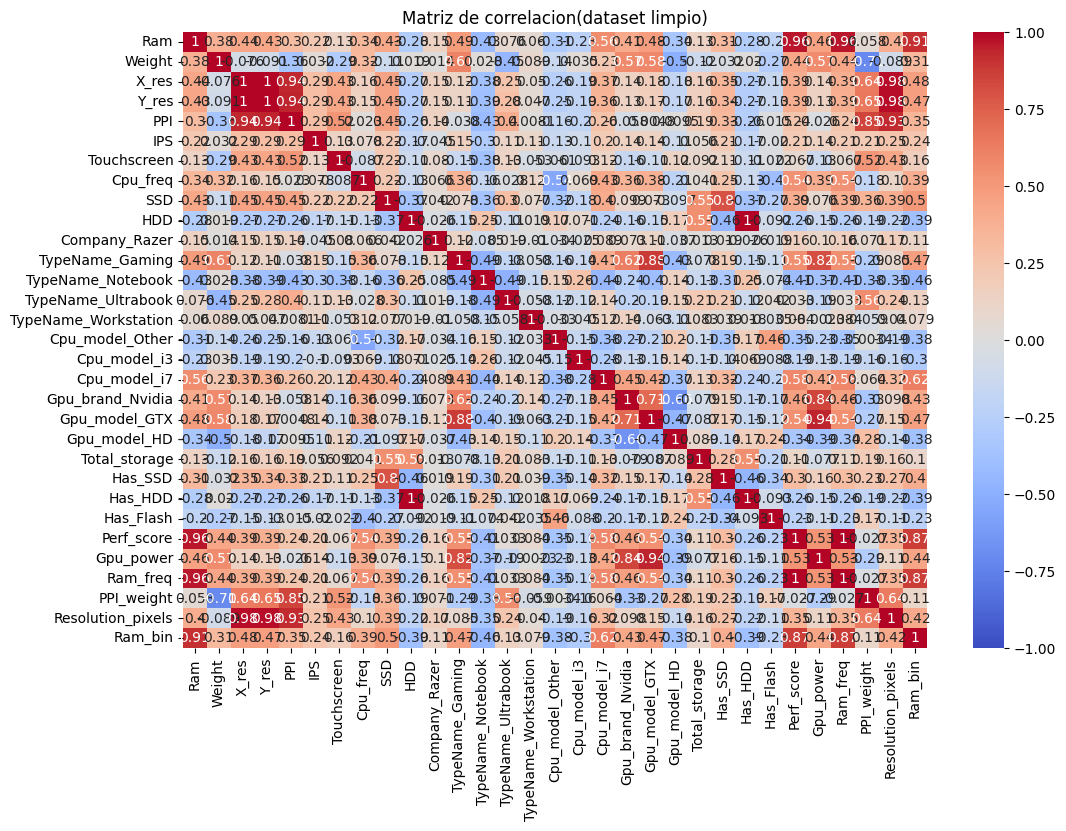

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,8))
sns.heatmap(
    X_train.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title('Matriz de correlacion(dataset limpio)')
plt.show()

In [22]:
X_train["Cpu_freq"].unique()
X_train["IPS"].unique()


array([1, 0])

In [23]:
X_train[["Cpu_freq", "IPS"]].corr()


,Cpu_freq,IPS
Cpu_freq,1.000000,0.078315
IPS,0.078315,1.000000


In [24]:
X_train["Cpu_freq"].value_counts()
X_train["IPS"].value_counts()


IPS
0    534
1    195
Name: count, dtype: int64

Eliminamos las variables muy correlacionadas entre ellas 

In [25]:
import numpy as np

corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = to_drop = ["X_res", "Y_res"]

X_train = X_train.drop(columns=to_drop)
X_test = X_test.drop(columns=to_drop)




In [26]:
X_train

,Ram,Weight,PPI,IPS,Touchscreen,Cpu_freq,SSD,HDD,Company_Razer,TypeName_Gaming,...,Total_storage,Has_SSD,Has_HDD,Has_Flash,Perf_score,Gpu_power,Ram_freq,PPI_weight,Resolution_pixels,Ram_bin
25,8,3.00,127.335675,1,0,2.6,0,0,False,False,...,0,0,0,0,20.8,0.0,20.8,42.445225,2073600,1
84,16,2.56,141.211998,0,0,2.8,512,0,False,True,...,512,1,0,0,44.8,5.0,44.8,55.160937,2073600,2
10,8,1.37,226.983005,1,0,2.9,512,0,False,False,...,512,1,0,0,23.2,0.0,23.2,165.681025,4096000,1
342,4,1.54,157.350512,0,0,2.3,0,500,False,False,...,500,0,1,0,9.2,1.0,9.2,102.175657,2073600,0
890,16,2.80,127.335675,0,0,1.8,256,0,False,False,...,256,1,0,0,28.8,0.0,28.8,45.477027,2073600,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,8,1.94,111.935204,0,0,1.6,0,0,False,False,...,0,0,0,0,12.8,1.0,12.8,57.698559,1049088,1
270,6,2.20,141.211998,0,0,3.6,256,0,False,False,...,256,1,0,0,21.6,0.0,21.6,64.187272,2073600,1
860,16,1.18,176.232574,0,0,2.8,256,0,False,False,...,256,1,0,0,44.8,1.0,44.8,149.349639,2073600,2
435,4,2.20,100.454670,0,0,1.1,0,0,False,False,...,0,0,0,0,4.4,1.0,4.4,45.661214,1049088,0


In [27]:
X_test

,Ram,Weight,PPI,IPS,Touchscreen,Cpu_freq,SSD,HDD,Company_Razer,TypeName_Gaming,...,Total_storage,Has_SSD,Has_HDD,Has_Flash,Perf_score,Gpu_power,Ram_freq,PPI_weight,Resolution_pixels,Ram_bin
649,8,2.20,141.211998,1,0,2.8,128,0,False,True,...,128,1,0,0,22.4,5.0,22.4,64.187272,2073600,1
761,8,2.08,141.211998,0,1,2.5,256,0,False,False,...,256,1,0,0,20.0,0.0,20.0,67.890384,2073600,1
545,8,1.87,157.350512,1,0,2.5,256,0,False,False,...,256,1,0,0,20.0,2.0,20.0,84.144659,2073600,1
367,4,1.63,157.350512,1,1,2.4,128,0,False,False,...,128,1,0,0,9.6,2.0,9.6,96.534057,2073600,0
361,4,2.20,100.454670,0,0,1.6,0,500,False,False,...,500,0,1,0,6.4,1.0,6.4,45.661214,1049088,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
344,8,1.86,141.211998,0,0,2.5,0,0,False,False,...,0,0,0,0,20.0,1.0,20.0,75.920429,2073600,1
581,4,1.25,135.094211,1,1,1.6,0,0,False,False,...,32,0,0,1,6.4,1.0,6.4,108.075369,1049088,0
872,2,1.15,135.094211,0,0,1.1,0,0,False,False,...,32,0,0,1,2.2,1.0,2.2,117.473227,1049088,0
449,8,1.87,157.350512,1,0,2.7,256,0,False,False,...,256,1,0,0,21.6,2.0,21.6,84.144659,2073600,1


Creamos una funcion para aplicar los cambios de X_train a X_test 

In [28]:
y_train

25     2899.00
84     1249.26
10     1958.90
342    1030.99
890    1396.00
        ...   
106     389.00
270     549.00
860    1859.00
435     306.00
102    1943.00
Name: Price_in_euros, Length: 729, dtype: float64

In [29]:
X_train.columns.equals(X_test.columns)


True

## 3. Procesado de datos

Nuestro target es la columna `Price_in_euros`

In [30]:
target = 'Price_in_euros'

In [31]:
df['Price_in_euros'].describe()

count     912.000000
mean     1111.724090
std       687.959172
min       174.000000
25%       589.000000
50%       978.000000
75%      1483.942500
max      6099.000000
Name: Price_in_euros, dtype: float64

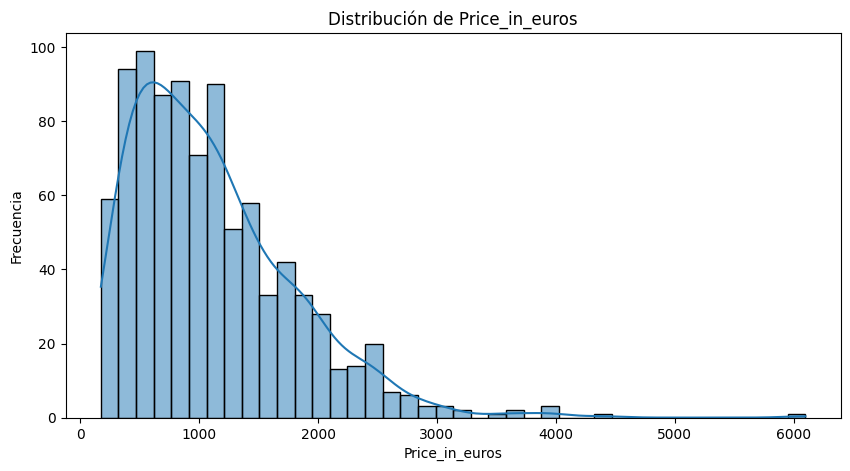

In [32]:
plt.figure(figsize=(10,5))
sns.histplot(df['Price_in_euros'], kde=True, bins=40)
plt.title("Distribución de Price_in_euros")
plt.xlabel("Price_in_euros")
plt.ylabel("Frecuencia")
plt.show()

Tiene mucha cola a la derecha y son modelos sensibles a escalas, modelo linal puede verse penalizado. Hacer transformacion log.

Buscar valores NaN en X_train

In [33]:
X_train.isnull().sum()


Ram                     0
Weight                  0
PPI                     0
IPS                     0
Touchscreen             0
Cpu_freq                0
SSD                     0
HDD                     0
Company_Razer           0
TypeName_Gaming         0
TypeName_Notebook       0
TypeName_Ultrabook      0
TypeName_Workstation    0
Cpu_model_Other         0
Cpu_model_i3            0
Cpu_model_i7            0
Gpu_brand_Nvidia        0
Gpu_model_GTX           0
Gpu_model_HD            0
Total_storage           0
Has_SSD                 0
Has_HDD                 0
Has_Flash               0
Perf_score              0
Gpu_power               0
Ram_freq                0
PPI_weight              0
Resolution_pixels       0
Ram_bin                 0
dtype: int64

Imputar valores nulos con la mediana


In [34]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train["Cpu_freq"] = imputer.fit_transform(X_train[["Cpu_freq"]])
X_test["Cpu_freq"] = imputer.transform(X_test[["Cpu_freq"]])

-----------------------------------------------------------------------------------------------------------------

## 4. Modelado

### 4.1 Baseline de modelos


In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

modelos = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}


Transformación logarítmica del target

GridSearch sobre el target

**Esto es un modelo con escala logaritmica del target pero no mejora el RMSE final por lo que no lo usaremos**

### 4.2 Sacar métricas, valorar los modelos

Recuerda que en la competición se va a evaluar con la métrica de ``RMSE``.

In [36]:
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    
    print(f"\nModelo: {nombre}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2: {r2:.3f}")



Modelo: LinearRegression
RMSE: 391.39
R2: 0.724

Modelo: RandomForest
RMSE: 384.77
R2: 0.733

Modelo: GradientBoosting
RMSE: 405.45
R2: 0.703


### Gradient Boosting Regresor

In [37]:
# best_model = GradientBoostingRegressor(
#     learning_rate=0.05,
#     max_depth=3,
#     n_estimators=500,
#     subsample=0.8,
#     random_state=42
# )

# best_model.fit(X_train, y_train)


### RandomForest


In [38]:
# best_model = RandomForestRegressor(
#     n_estimators=300,
#     max_depth=10,
#     min_samples_split=2,
#     min_samples_leaf=1,
#     max_features="sqrt",
#     random_state=42
# )

# best_model.fit(X_train, y_train)


### XGBoost

In [41]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 1.3 MB/s eta 0:01:20
   ---------------------------------------- 1.0/101.7 MB 1.5 MB/s eta 0:01:08
    --------------------------------------- 1.6/101.7 MB 1.7 MB/s eta 0:01:01
    --------------------------------------- 2.1/101.7 MB 1.8 MB/s eta 0:00:55
    --------------------------------------- 2.4/101.7 MB 1.9 MB/s eta 0:00:54
   - -------------------------------------- 2.6/101.7 MB 1.9 MB/s eta 0:00:54
   - -------------------------------------- 2.9/101.7 MB 1.7 MB/s eta 0:00:58
   - -------------------------------------- 3.1/101.7 MB 1.7 MB/s eta 0:00:59
   - -------------------------------------- 3.7/101.7 MB 1.7 MB/s eta 0:00:59
   - -------------------------------------- 4.2/101.7 MB 1.7 MB/s eta 0:00:57
   - --


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
from xgboost import XGBRegressor

best_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.7,
    colsample_bytree=0.6,
    random_state=42
)

best_model.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [43]:
pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("RMSE final:", rmse)
print("R2 final:", r2)


RMSE final: 336.8812315278851
R2 final: 0.7952260242455744


Calcular RSME en euros

In [44]:
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("RMSE final:", rmse)
print("R2 final:", r2)

RMSE final: 336.8812315278851
R2 final: 0.7952260242455744


### 4.3 Optimización (up to you 🫰🏻)

-----------------------------------------------------------------

Tunning hiperparámetros

In [45]:
#GradientBoostingRegresor

from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 300, 500],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0]
}

grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor RMSE:", -grid.best_score_)

Mejores parámetros: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500, 'subsample': 1.0}
Mejor RMSE: 278.6894739653804


In [46]:
#RandomForest Regresor

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 5, 10, 20],
    "max_features": ["auto", "sqrt", "log2"],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor RMSE:", -grid.best_score_);

c:\Users\blanc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
540 fits failed out of a total of 1620.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
212 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\blanc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\blanc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c

Mejores parámetros: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Mejor RMSE: 294.17820079254193


In [47]:
#XGBoost

from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist"   # mucho más rápido
)

param_dist = {
    "n_estimators": [300, 500, 800, 1200],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 8],
    "subsample": [0.6, 0.7, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.2, 0.3]
}

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=40,                 # buen equilibrio entre tiempo y calidad
    scoring="neg_root_mean_squared_error",
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

print("Mejores parámetros:", search.best_params_)
print("Mejor RMSE:", -search.best_score_)


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Mejores parámetros: {'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.03, 'gamma': 0.1, 'colsample_bytree': 0.6}
Mejor RMSE: 283.43774508555043


Guardar el modelo entrenado

In [48]:
import joblib

joblib.dump(best_model, "modelo_final.pkl")

['modelo_final.pkl']

In [49]:
import joblib

model = joblib.load("modelo_final.pkl")


## Una vez listo el modelo, toca predecir ``test.csv``

**RECUERDA: APLICAR LAS TRANSFORMACIONES QUE HAYAS REALIZADO EN `train.csv` a `test.csv`.**


Véase:
- Estandarización/Normalización
- Eliminación de Outliers
- Eliminación de columnas
- Creación de columnas nuevas
- Gestión de valores nulos
- Y un largo etcétera de técnicas que como Data Scientist hayas considerado las mejores para tu dataset.

## 1. Carga los datos de `test.csv` para predecir.


In [50]:
X_pred_raw = pd.read_csv("./data/test.csv")
X_pred = preprocess_features(X_pred_raw)


C:\Users\blanc\AppData\Local\Temp\ipykernel_7452\3455898259.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Cpu_gen"] = df["Cpu_gen"].fillna(0).astype(int)


In [51]:
X_pred = X_pred.reindex(columns=X_train.columns, fill_value=0)


In [52]:
X_pred.tail()

,Ram,Weight,PPI,IPS,Touchscreen,Cpu_freq,SSD,HDD,Company_Razer,TypeName_Gaming,...,Total_storage,Has_SSD,Has_HDD,Has_Flash,Perf_score,Gpu_power,Ram_freq,PPI_weight,Resolution_pixels,Ram_bin
386,16,2.90,127.335675,0,0,2.8,512,0,False,True,...,512,1,0,0,44.8,5.0,44.8,43.908853,2073600,2
387,4,1.47,157.350512,1,0,2.3,128,0,False,False,...,128,1,0,0,9.2,1.0,9.2,107.041165,2073600,0
388,8,1.78,141.211998,0,0,2.8,256,0,False,False,...,256,1,0,0,22.4,2.0,22.4,79.332583,2073600,1
389,4,1.64,111.935204,0,0,2.5,0,500,False,False,...,500,0,1,0,10.0,1.0,10.0,68.253173,1049088,0
390,8,1.27,165.632118,1,1,2.5,256,0,False,False,...,256,1,0,0,20.0,1.0,20.0,130.418991,2073600,1


In [53]:
X_pred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391 entries, 0 to 390
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Ram                   391 non-null    int64  
 1   Weight                391 non-null    float64
 2   PPI                   391 non-null    float64
 3   IPS                   391 non-null    int64  
 4   Touchscreen           391 non-null    int64  
 5   Cpu_freq              391 non-null    float64
 6   SSD                   391 non-null    int64  
 7   HDD                   391 non-null    int64  
 8   Company_Razer         391 non-null    bool   
 9   TypeName_Gaming       391 non-null    bool   
 10  TypeName_Notebook     391 non-null    bool   
 11  TypeName_Ultrabook    391 non-null    bool   
 12  TypeName_Workstation  391 non-null    bool   
 13  Cpu_model_Other       391 non-null    bool   
 14  Cpu_model_i3          391 non-null    bool   
 15  Cpu_model_i7          3

Quitar los Nan

In [54]:
cpu_median = X_train["Cpu_freq"].median()

X_pred["Cpu_freq"] = X_pred["Cpu_freq"].fillna(cpu_median)

In [55]:
X_pred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391 entries, 0 to 390
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Ram                   391 non-null    int64  
 1   Weight                391 non-null    float64
 2   PPI                   391 non-null    float64
 3   IPS                   391 non-null    int64  
 4   Touchscreen           391 non-null    int64  
 5   Cpu_freq              391 non-null    float64
 6   SSD                   391 non-null    int64  
 7   HDD                   391 non-null    int64  
 8   Company_Razer         391 non-null    bool   
 9   TypeName_Gaming       391 non-null    bool   
 10  TypeName_Notebook     391 non-null    bool   
 11  TypeName_Ultrabook    391 non-null    bool   
 12  TypeName_Workstation  391 non-null    bool   
 13  Cpu_model_Other       391 non-null    bool   
 14  Cpu_model_i3          391 non-null    bool   
 15  Cpu_model_i7          3

 ## 2. Replicar el procesado para ``test.csv``

In [56]:
X_pred

,Ram,Weight,PPI,IPS,Touchscreen,Cpu_freq,SSD,HDD,Company_Razer,TypeName_Gaming,...,Total_storage,Has_SSD,Has_HDD,Has_Flash,Perf_score,Gpu_power,Ram_freq,PPI_weight,Resolution_pixels,Ram_bin
0,16,2.400,141.211998,0,0,2.8,512,0,False,True,...,512,1,0,0,44.8,5.0,44.8,58.838333,2073600,2
1,4,2.400,100.454670,0,0,1.6,0,500,False,False,...,500,0,1,0,6.4,1.0,6.4,41.856112,1049088,0
2,4,1.900,100.454670,0,0,2.0,0,0,False,False,...,0,0,0,0,8.0,1.0,8.0,52.870879,1049088,0
3,8,2.191,141.211998,1,1,2.5,256,0,False,False,...,256,1,0,0,20.0,1.0,20.0,64.450935,2073600,1
4,4,1.950,157.350512,0,0,2.5,256,0,False,False,...,256,1,0,0,10.0,1.0,10.0,80.692570,2073600,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
386,16,2.900,127.335675,0,0,2.8,512,0,False,True,...,512,1,0,0,44.8,5.0,44.8,43.908853,2073600,2
387,4,1.470,157.350512,1,0,2.3,128,0,False,False,...,128,1,0,0,9.2,1.0,9.2,107.041165,2073600,0
388,8,1.780,141.211998,0,0,2.8,256,0,False,False,...,256,1,0,0,22.4,2.0,22.4,79.332583,2073600,1
389,4,1.640,111.935204,0,0,2.5,0,500,False,False,...,500,0,1,0,10.0,1.0,10.0,68.253173,1049088,0


In [57]:
predictions_submit = model.predict(X_pred)
predictions_submit

array([1435.806  ,  335.1122 ,  395.97998,  980.44135,  801.48224,
        514.89905,  695.1463 , 1026.6118 , 1303.9658 ,  338.80505,
       2643.4844 , 1321.0079 ,  470.24515, 1565.5997 ,  872.6495 ,
        670.5666 , 1749.27   , 1367.6108 , 1839.3097 ,  667.75287,
       1518.3976 ,  294.02866,  653.3524 , 1395.1411 ,  384.70822,
        697.72424,  503.84824,  688.6867 , 2192.9597 , 1005.5485 ,
       1985.1868 ,  390.18323,  754.6228 , 2977.0347 , 2075.48   ,
       2003.5956 ,  572.13745, 1325.1526 ,  920.89996, 1521.8938 ,
        714.57214,  765.27185,  511.8229 , 1152.476  , 1246.0536 ,
       1046.191  , 1011.16473,  455.19116,  832.351  ,  446.88297,
       2129.6843 ,  748.03107, 1171.6979 ,  612.9568 , 1926.2832 ,
       1855.3413 ,  734.867  ,  911.3002 ,  885.4441 ,  612.7128 ,
       3348.4482 , 1866.2561 ,  564.7761 , 2070.7417 , 1235.3967 ,
       1258.4329 ,  938.23456, 1349.4993 , 1715.2754 , 1937.06   ,
        863.141  ,  555.6261 , 1029.1813 , 1734.1859 , 1028.36

**¡OJO! ¿Por qué me da error?**

IMPORTANTE:

- SI EL ARRAY CON EL QUE HICISTEIS `.fit()` ERA DE 4 COLUMNAS, PARA `.predict()` DEBEN SER LAS MISMAS
- SI AL ARRAY CON EL QUE HICISTEIS `.fit()` LO NORMALIZASTEIS, PARA `.predict()` DEBÉIS NORMALIZARLO
- TODO IGUAL SALVO **BORRAR FILAS**, EL NÚMERO DE ROWS SE DEBE MANTENER EN ESTE SET, PUES LA PREDICCIÓN DEBE TENER **391 FILAS**, SI O SI

**Entonces, si al cargar los datos de ``train.csv`` usaste `index_col=0`, ¿tendré que hacer lo también para el `test.csv`?**

In [58]:
# ¿Qué opináis?
# ¿Sí, no?

![wow.jpeg](attachment:wow.jpeg)

## 3. **¿Qué es lo que subirás a Kaggle?**

**Para subir a Kaggle la predicción esta tendrá que tener una forma específica.**

En este caso, la **MISMA** forma que `sample_submission.csv`.

In [59]:
sample = pd.read_csv("data/sample_submission.csv")

In [60]:
sample.head()

,laptop_ID,Price_in_euros
0,209,1949.1
1,1281,805.0
2,1168,1101.0
3,1231,1293.8
4,1020,1832.6


In [61]:
sample.shape

(391, 2)

## 4. Mete tus predicciones en un dataframe llamado ``submission``.

In [62]:
#¿Cómo creamos la submission?
submission = pd.DataFrame({
    "laptop_ID": X_pred_raw["laptop_ID"],
    "Price_in_euros": predictions_submit
})


In [63]:
submission.head()

,laptop_ID,Price_in_euros
0,209,1435.806030
1,1281,335.112213
2,1168,395.979980
3,1231,980.441345
4,1020,801.482239


In [64]:
submission.shape

(391, 2)

## 5. Pásale el CHEQUEADOR para comprobar que efectivamente está listo para subir a Kaggle.

In [65]:
def chequeador(df_to_submit):
    """
    Esta función se asegura de que tu submission tenga la forma requerida por Kaggle.

    Si es así, se guardará el dataframe en un `csv` y estará listo para subir a Kaggle.

    Si no, LEE EL MENSAJE Y HAZLE CASO.

    Si aún no:
    - apaga tu ordenador,
    - date una vuelta,
    - enciendelo otra vez,
    - abre este notebook y
    - leelo todo de nuevo.
    Todos nos merecemos una segunda oportunidad. También tú.
    """
    if df_to_submit.shape == sample.shape:
        if df_to_submit.columns.all() == sample.columns.all():
            if df_to_submit.laptop_ID.all() == sample.laptop_ID.all():
                print("You're ready to submit!")
                df_to_submit.to_csv("submission.csv", index = False) #muy importante el index = False
                urllib.request.urlretrieve("https://www.mihaileric.com/static/evaluation-meme-e0a350f278a36346e6d46b139b1d0da0-ed51e.jpg", "gfg.png")
                img = Image.open("gfg.png")
                img.show()
            else:
                print("Check the ids and try again")
        else:
            print("Check the names of the columns and try again")
    else:
        print("Check the number of rows and/or columns and try again")
        print("\nMensaje secreto del TA: No me puedo creer que después de todo este notebook hayas hecho algún cambio en las filas de `test.csv`. Lloro.")

In [66]:
chequeador(submission)

You're ready to submit!
